In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

print("VAE Matematiği — ELBO Türetimi")
print("=" * 40)
print()
print("Bugün cevaplayacağımız sorular:")
print("1. Generatif model nedir — P(x) nasıl öğrenilir?")
print("2. Posterior P(z|x) neden hesaplanamaz?")
print("3. Variational Inference — yaklaşık çözüm")
print("4. ELBO nedir ve nasıl türetilir?")
print("5. Reparameterization trick — neden şart?")
print("6. Sıfırdan VAE implement et")
print()
print("Anahtar: VAE = Encoder + Decoder + KL cezası")

torch.manual_seed(42)
np.random.seed(42)

VAE Matematiği — ELBO Türetimi

Bugün cevaplayacağımız sorular:
1. Generatif model nedir — P(x) nasıl öğrenilir?
2. Posterior P(z|x) neden hesaplanamaz?
3. Variational Inference — yaklaşık çözüm
4. ELBO nedir ve nasıl türetilir?
5. Reparameterization trick — neden şart?
6. Sıfırdan VAE implement et

Anahtar: VAE = Encoder + Decoder + KL cezası


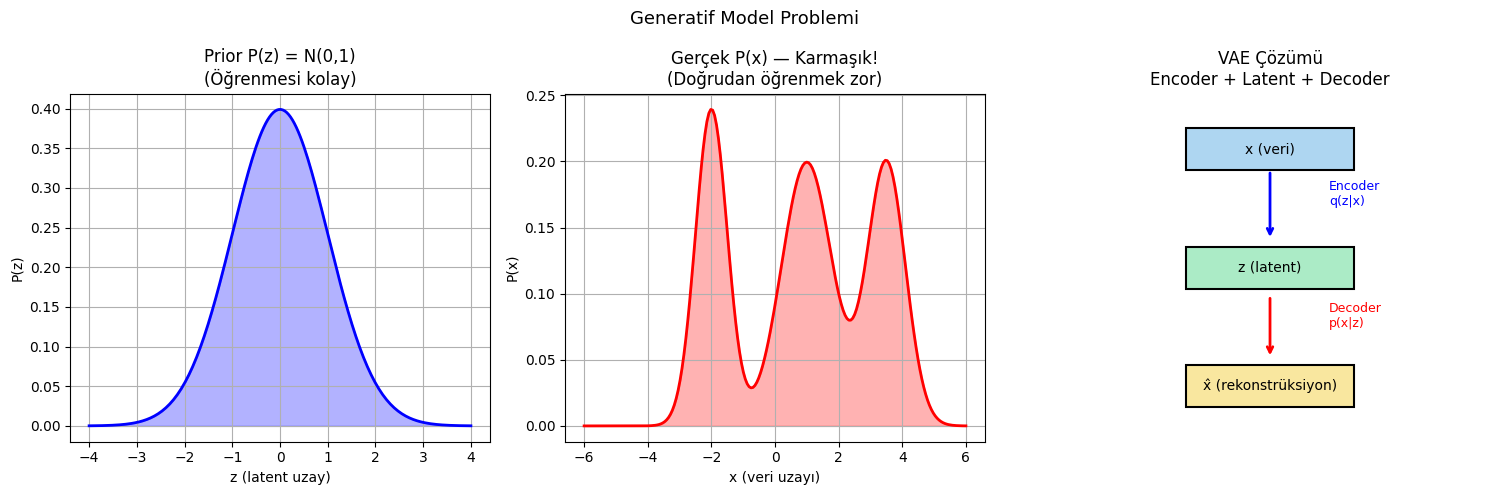

Problem:
P(x) = ∫ P(x|z) * P(z) dz
Bu integral → hesaplanamaz (intractable)!

Çözüm: Variational Inference
Gerçek posterior P(z|x) yerine
yaklaşık q(z|x) kullan!


In [2]:
# GENERATİF MODEL PROBLEMİ
#
# Hedef: P(x) öğren — yeni veri üret
#
# Latent variable model:
# P(x) = ∫ P(x|z) * P(z) dz
#
# P(z) = N(0,I)  ← prior (basit Gaussian)
# P(x|z) = decoder (karmaşık fonksiyon)
#
# Problem: Bu integral hesaplanamaz!
# Çözüm: Variational Inference

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Prior P(z) — basit Gaussian
z_range = np.linspace(-4, 4, 200)
prior = norm.pdf(z_range, 0, 1)

axes[0].plot(z_range, prior, 'b-', linewidth=2)
axes[0].fill_between(z_range, prior, alpha=0.3, color='blue')
axes[0].set_title("Prior P(z) = N(0,1)\n(Öğrenmesi kolay)")
axes[0].set_xlabel("z (latent uzay)")
axes[0].set_ylabel("P(z)")
axes[0].grid(True)

# Gerçek veri dağılımı — karmaşık
x_range = np.linspace(-6, 6, 200)
# Çok modlu dağılım simülasyonu
p_x = (0.3 * norm.pdf(x_range, -2, 0.5) +
       0.4 * norm.pdf(x_range, 1, 0.8) +
       0.3 * norm.pdf(x_range, 3.5, 0.6))

axes[1].plot(x_range, p_x, 'r-', linewidth=2)
axes[1].fill_between(x_range, p_x, alpha=0.3, color='red')
axes[1].set_title("Gerçek P(x) — Karmaşık!\n(Doğrudan öğrenmek zor)")
axes[1].set_xlabel("x (veri uzayı)")
axes[1].set_ylabel("P(x)")
axes[1].grid(True)

# VAE çözümü
axes[2].axis('off')
axes[2].set_xlim(0, 5)
axes[2].set_ylim(0, 5)

# Şema çiz
for y, label, renk in [(4.2, 'x (veri)', '#AED6F1'),
                        (2.5, 'z (latent)', '#ABEBC6'),
                        (0.8, 'x̂ (rekonstrüksiyon)', '#F9E79F')]:
    axes[2].add_patch(plt.Rectangle((1.5, y-0.3), 2, 0.6,
                     facecolor=renk, edgecolor='black', linewidth=1.5))
    axes[2].text(2.5, y, label, ha='center', va='center', fontsize=10)

axes[2].annotate('', xy=(2.5, 2.9), xytext=(2.5, 3.9),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
axes[2].text(3.2, 3.4, 'Encoder\nq(z|x)', fontsize=9, color='blue')

axes[2].annotate('', xy=(2.5, 1.2), xytext=(2.5, 2.1),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
axes[2].text(3.2, 1.65, 'Decoder\np(x|z)', fontsize=9, color='red')

axes[2].set_title("VAE Çözümü\nEncoder + Latent + Decoder")

plt.suptitle("Generatif Model Problemi", fontsize=13)
plt.tight_layout()
plt.show()

print("Problem:")
print("P(x) = ∫ P(x|z) * P(z) dz")
print("Bu integral → hesaplanamaz (intractable)!")
print()
print("Çözüm: Variational Inference")
print("Gerçek posterior P(z|x) yerine")
print("yaklaşık q(z|x) kullan!")

ELBO TÜRETİMİ

log P(x) = log ∫ P(x|z) P(z) dz          [Marjinalleştir]

         = log ∫ q(z|x) * P(x|z)P(z)/q(z|x) dz  [q ekle]

         = log E_q[P(x|z)P(z)/q(z|x)]     [Beklenti]

         ≥ E_q[log P(x|z)P(z)/q(z|x)]     [Jensen ≤]

         = E_q[log P(x|z)] + E_q[log P(z)/q(z|x)]

         = E_q[log P(x|z)] - KL(q(z|x) || P(z))
           ─────────────────  ─────────────────────
           Rekonstrüksiyon    Regularizasyon
           terimi             terimi (KL)

ELBO = Rekonstrüksiyon - KL



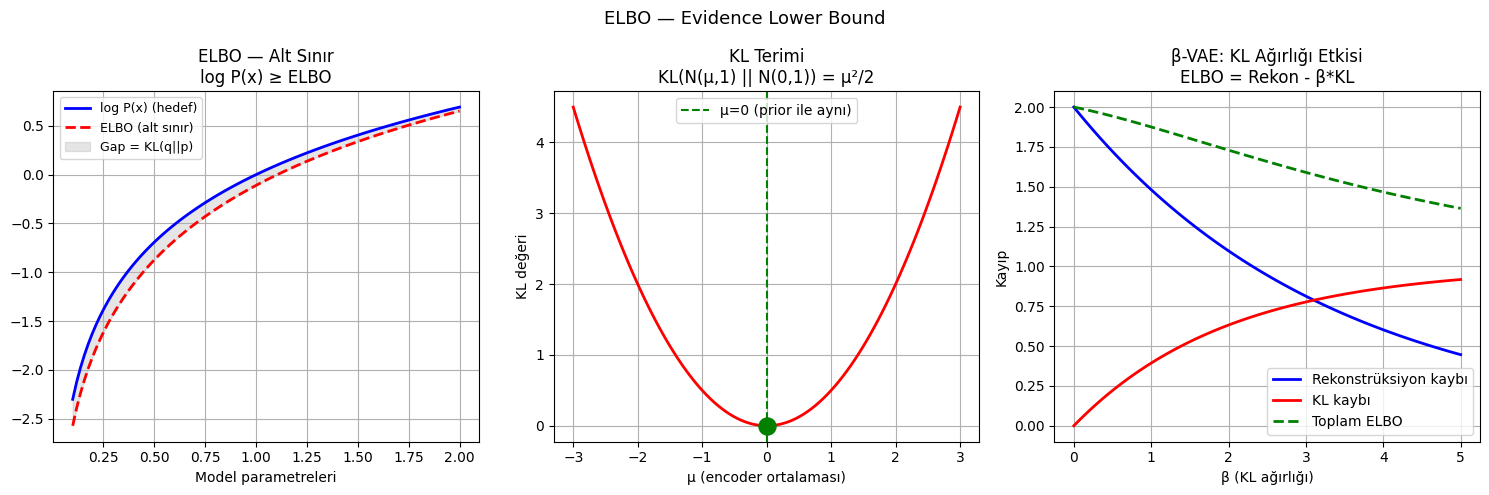

Gaussian için analitik KL formülü:
KL(N(μ,σ²) || N(0,1)) = 0.5 * Σ(μ² + σ² - 1 - log σ²)

Bu formül çok önemli — VAE loss'unun KL terimi buradan gelir!

μ=[0.5 1.  2. ], σ=[0.8 1.  1.5]
KL = [0.1681 0.5    2.2195]


In [3]:
# ELBO TÜRETİMİ
#
# Hedef: log P(x) maksimize et
#
# log P(x) = log ∫ P(x|z) P(z) dz
#
# q(z|x) ekleyelim (çarp ve böl):
# = log ∫ P(x|z) P(z) * q(z|x)/q(z|x) dz
#
# Jensen eşitsizliği (log konkav):
# ≥ ∫ q(z|x) * log[P(x|z) P(z) / q(z|x)] dz
#
# = E_q[log P(x|z)] - KL(q(z|x) || P(z))
#
# Bu = ELBO (Evidence Lower BOund)
# log P(x) ≥ ELBO
# ELBO'yu maksimize et = log P(x)'e yaklaş!

print("=" * 55)
print("ELBO TÜRETİMİ")
print("=" * 55)
print("""
log P(x) = log ∫ P(x|z) P(z) dz          [Marjinalleştir]

         = log ∫ q(z|x) * P(x|z)P(z)/q(z|x) dz  [q ekle]

         = log E_q[P(x|z)P(z)/q(z|x)]     [Beklenti]

         ≥ E_q[log P(x|z)P(z)/q(z|x)]     [Jensen ≤]

         = E_q[log P(x|z)] + E_q[log P(z)/q(z|x)]

         = E_q[log P(x|z)] - KL(q(z|x) || P(z))
           ─────────────────  ─────────────────────
           Rekonstrüksiyon    Regularizasyon
           terimi             terimi (KL)

ELBO = Rekonstrüksiyon - KL
""")

# ELBO'nun geometrik yorumu
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# log P(x) vs ELBO
lambda_range = np.linspace(0.1, 2, 100)
log_px = np.log(lambda_range)
# ELBO her zaman log P(x)'den küçük
elbo = log_px - 0.3 * np.exp(-lambda_range)

axes[0].plot(lambda_range, log_px, 'b-', linewidth=2, label='log P(x) (hedef)')
axes[0].plot(lambda_range, elbo, 'r--', linewidth=2, label='ELBO (alt sınır)')
axes[0].fill_between(lambda_range, elbo, log_px, alpha=0.2,
                    color='gray', label='Gap = KL(q||p)')
axes[0].set_title("ELBO — Alt Sınır\nlog P(x) ≥ ELBO")
axes[0].set_xlabel("Model parametreleri")
axes[0].legend(fontsize=9)
axes[0].grid(True)

# KL terimi — q ve prior arasındaki mesafe
mu_range = np.linspace(-3, 3, 100)
sigma = 1.0
# Gaussian KL: KL(N(μ,σ²) || N(0,1)) = 0.5*(μ² + σ² - 1 - log σ²)
kl_values = 0.5 * (mu_range**2 + sigma**2 - 1 - np.log(sigma**2))

axes[1].plot(mu_range, kl_values, 'r-', linewidth=2)
axes[1].axvline(x=0, color='green', linestyle='--', label='μ=0 (prior ile aynı)')
axes[1].scatter([0], [0], color='green', s=150, zorder=5)
axes[1].set_title("KL Terimi\nKL(N(μ,1) || N(0,1)) = μ²/2")
axes[1].set_xlabel("μ (encoder ortalaması)")
axes[1].set_ylabel("KL değeri")
axes[1].legend()
axes[1].grid(True)

# İki terim arasındaki denge
beta_values = np.linspace(0, 5, 100)
recon = 2.0 * np.exp(-0.3 * beta_values)  # KL cezası artınca rekon zorlaşır
kl = 1 - np.exp(-0.5 * beta_values)       # KL cezası artınca KL azalır

axes[2].plot(beta_values, recon, 'b-', linewidth=2, label='Rekonstrüksiyon kaybı')
axes[2].plot(beta_values, kl, 'r-', linewidth=2, label='KL kaybı')
axes[2].plot(beta_values, recon+kl, 'g--', linewidth=2, label='Toplam ELBO')
axes[2].set_title("β-VAE: KL Ağırlığı Etkisi\nELBO = Rekon - β*KL")
axes[2].set_xlabel("β (KL ağırlığı)")
axes[2].set_ylabel("Kayıp")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("ELBO — Evidence Lower Bound", fontsize=13)
plt.tight_layout()
plt.show()

# Gaussian için analitik KL
print("Gaussian için analitik KL formülü:")
print("KL(N(μ,σ²) || N(0,1)) = 0.5 * Σ(μ² + σ² - 1 - log σ²)")
print()
print("Bu formül çok önemli — VAE loss'unun KL terimi buradan gelir!")
print()

# Doğrula
mu_test = np.array([0.5, 1.0, 2.0])
sigma_test = np.array([0.8, 1.0, 1.5])
kl_analitik = 0.5 * (mu_test**2 + sigma_test**2 - 1 - np.log(sigma_test**2))
print(f"μ={mu_test}, σ={sigma_test}")
print(f"KL = {kl_analitik.round(4)}")

=== REPARAMETERİZASYON TRICK PyTorch ===

μ shape: torch.Size([4, 2])
log_var shape: torch.Size([4, 2])
z shape: torch.Size([4, 2])

μ:
[[ 1.  -0.5]
 [ 0.3  1.2]
 [-0.8  0.7]
 [ 0.5 -1. ]]

z (örneklenmiş):
[[ 1.262 -0.35 ]
 [ 0.546  1.408]
 [-2.171  0.575]
 [ 2.401 -1.861]]

✅ μ gradyanı: [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
✅ log_var gradyanı: [[ 0.18   0.155]
 [ 0.281  0.366]
 [ 0.678 -0.566]
 [-0.426  0.647]]

Gradyanlar başarıyla hesaplandı!


C:\Users\PC\AppData\Local\Temp\ipykernel_26944\677965529.py:145: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_26944\677965529.py:145: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


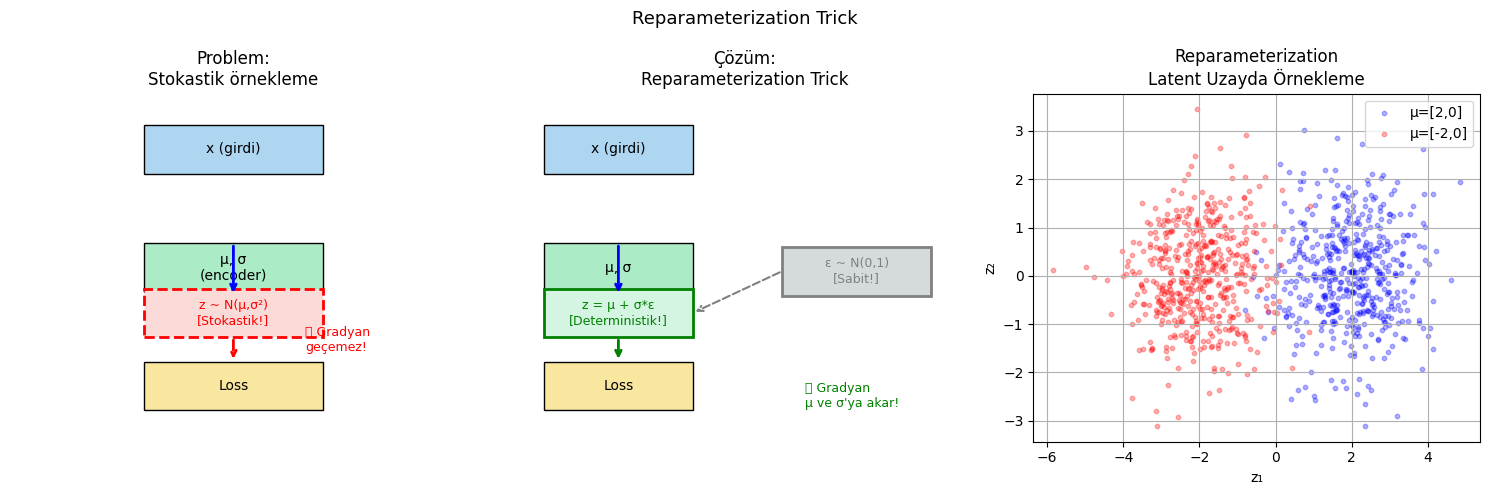

In [4]:
# REPARAMETERİZASYON TRICK
#
# Problem: z ~ q(z|x) = N(μ, σ²)
# z'den örnekleme yap → gradyan geçemez!
#
# Neden? Örnekleme stokastik → türev yok!
#
# Çözüm: z = μ + σ * ε,  ε ~ N(0,1)
# Artık gradyan μ ve σ'ya göre hesaplanabilir!
# Stokastisite ε'a taşındı — ε'a göre gradyan gerekmez!

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Problem görselleştirme
ax = axes[0]
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.axis('off')

# Gradyan geçemeyen yol
for y, label, renk in [(4.2, 'x (girdi)', '#AED6F1'),
                        (2.5, 'μ, σ\n(encoder)', '#ABEBC6'),
                        (0.8, 'Loss', '#F9E79F')]:
    ax.add_patch(plt.Rectangle((1.5, y-0.35), 2, 0.7,
                facecolor=renk, edgecolor='black'))
    ax.text(2.5, y, label, ha='center', va='center', fontsize=10)

# Stokastik örnekleme bloğu
ax.add_patch(plt.Rectangle((1.5, 1.5), 2, 0.7,
            facecolor='#FADBD8', edgecolor='red', linewidth=2,
            linestyle='--'))
ax.text(2.5, 1.85, 'z ~ N(μ,σ²)\n[Stokastik!]', ha='center',
       va='center', fontsize=9, color='red')

ax.annotate('', xy=(2.5, 2.1), xytext=(2.5, 2.85),
           arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.annotate('', xy=(2.5, 1.15), xytext=(2.5, 1.5),
           arrowprops=dict(arrowstyle='->', color='red', lw=2,
                          linestyle='dashed'))
ax.text(3.3, 1.3, '❌ Gradyan\ngeçemez!', fontsize=9, color='red')
ax.set_title("Problem:\nStokastik örnekleme")

# Reparameterization çözümü
ax2 = axes[1]
ax2.set_xlim(0, 6)
ax2.set_ylim(0, 5)
ax2.axis('off')

for x, y, label, renk in [(0.3, 4.2, 'x (girdi)', '#AED6F1'),
                           (0.3, 2.5, 'μ, σ', '#ABEBC6'),
                           (0.3, 0.8, 'Loss', '#F9E79F')]:
    ax2.add_patch(plt.Rectangle((x, y-0.35), 2, 0.7,
                 facecolor=renk, edgecolor='black'))
    ax2.text(x+1, y, label, ha='center', va='center', fontsize=10)

# Epsilon
ax2.add_patch(plt.Rectangle((3.5, 2.1), 2, 0.7,
             facecolor='#D5DBDB', edgecolor='gray', linewidth=2))
ax2.text(4.5, 2.45, 'ε ~ N(0,1)\n[Sabit!]', ha='center',
        va='center', fontsize=9, color='gray')

# z = μ + σε
ax2.add_patch(plt.Rectangle((0.3, 1.5), 2, 0.7,
             facecolor='#D5F5E3', edgecolor='green', linewidth=2))
ax2.text(1.3, 1.85, 'z = μ + σ*ε\n[Deterministik!]',
        ha='center', va='center', fontsize=9, color='green')

ax2.annotate('', xy=(1.3, 2.1), xytext=(1.3, 2.85),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax2.annotate('', xy=(1.3, 1.15), xytext=(1.3, 1.5),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax2.annotate('', xy=(2.3, 1.85), xytext=(3.5, 2.45),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5,
                           linestyle='dashed'))

ax2.text(3.8, 0.5, '✅ Gradyan\nμ ve σ\'ya akar!', fontsize=9, color='green')
ax2.set_title("Çözüm:\nReparameterization Trick")

# PyTorch ile göster
print("=== REPARAMETERİZASYON TRICK PyTorch ===\n")

torch.manual_seed(42)
batch_size = 4
latent_dim = 2

# Encoder çıktısı
mu = torch.tensor([[1.0, -0.5],
                   [0.3, 1.2],
                   [-0.8, 0.7],
                   [0.5, -1.0]])
log_var = torch.tensor([[-0.5, 0.3],
                         [0.1, -0.2],
                         [0.4, -0.8],
                         [-0.3, 0.6]])

# YANLIŞ yol — gradyan geçmez
# z = torch.normal(mu, torch.exp(0.5 * log_var))

# DOĞRU yol — reparameterization
def reparameterize(mu, log_var):
    std = torch.exp(0.5 * log_var)  # σ = exp(log σ²/2)
    eps = torch.randn_like(std)     # ε ~ N(0,1)
    z = mu + eps * std              # z = μ + σ*ε
    return z

z = reparameterize(mu, log_var)
print(f"μ shape: {mu.shape}")
print(f"log_var shape: {log_var.shape}")
print(f"z shape: {z.shape}")
print(f"\nμ:\n{mu.numpy().round(3)}")
print(f"\nz (örneklenmiş):\n{z.detach().numpy().round(3)}")

# Gradyan kontrolü
mu_grad = mu.clone().requires_grad_(True)
log_var_grad = log_var.clone().requires_grad_(True)
z_grad = reparameterize(mu_grad, log_var_grad)
loss = z_grad.sum()
loss.backward()
print(f"\n✅ μ gradyanı: {mu_grad.grad.numpy().round(3)}")
print(f"✅ log_var gradyanı: {log_var_grad.grad.numpy().round(3)}")
print("\nGradyanlar başarıyla hesaplandı!")

# Latent uzay görselleştirme
n_samples = 1000
mu_vis = torch.zeros(n_samples, 2)
log_var_vis = torch.zeros(n_samples, 2)

# Farklı μ değerleri
mu_vis[:500] = torch.tensor([2.0, 0.0])
mu_vis[500:] = torch.tensor([-2.0, 0.0])

z_vis = reparameterize(mu_vis, log_var_vis).detach().numpy()

axes[2].scatter(z_vis[:500, 0], z_vis[:500, 1],
               alpha=0.3, color='blue', s=10, label='μ=[2,0]')
axes[2].scatter(z_vis[500:, 0], z_vis[500:, 1],
               alpha=0.3, color='red', s=10, label='μ=[-2,0]')
axes[2].set_title("Reparameterization\nLatent Uzayda Örnekleme")
axes[2].set_xlabel("z₁")
axes[2].set_ylabel("z₂")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Reparameterization Trick", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# TAM VAE IMPLEMENTATION — MNIST

import torchvision
import torchvision.transforms as transforms

# Veri
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # 28x28 → 784
])

train_data = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=128, shuffle=False)

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: x → μ, log_var
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

        # Decoder: z → x̂
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Piksel değerleri 0-1
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var

def vae_loss(x_recon, x, mu, log_var, beta=1.0):
    # Rekonstrüksiyon kaybı — Binary Cross Entropy
    recon_loss = F.binary_cross_entropy(
        x_recon, x, reduction='sum') / x.shape[0]

    # KL kaybı — analitik formül
    # KL(N(μ,σ²) || N(0,1)) = -0.5 * Σ(1 + log σ² - μ² - σ²)
    kl_loss = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp()
    ) / x.shape[0]

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

# Model oluştur ve eğit
vae = VAE(input_dim=784, hidden_dim=400, latent_dim=20)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

print(f"VAE parametreleri: {sum(p.numel() for p in vae.parameters()):,}")
print("\nEğitim başlıyor — 10 epoch...")

train_losses = []
recon_losses = []
kl_losses = []

for epoch in range(10):
    vae.train()
    total_loss = total_recon = total_kl = 0

    for x, _ in train_loader:
        optimizer.zero_grad()
        x_recon, mu, log_var = vae(x)
        loss, recon, kl = vae_loss(x_recon, x, mu, log_var)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(train_loader)
    train_losses.append(total_loss/n)
    recon_losses.append(total_recon/n)
    kl_losses.append(total_kl/n)

    print(f"Epoch {epoch+1:2d}/10 | "
          f"Loss: {total_loss/n:.2f} | "
          f"Rekon: {total_recon/n:.2f} | "
          f"KL: {total_kl/n:.2f}")

VAE parametreleri: 973,624

Eğitim başlıyor — 10 epoch...
Epoch  1/10 | Loss: 178.37 | Rekon: 170.62 | KL: 7.75
Epoch  2/10 | Loss: 129.23 | Rekon: 114.76 | KL: 14.46
Epoch  3/10 | Loss: 117.67 | Rekon: 101.09 | KL: 16.58
Epoch  4/10 | Loss: 112.39 | Rekon: 94.43 | KL: 17.96
Epoch  5/10 | Loss: 109.22 | Rekon: 90.50 | KL: 18.71
Epoch  6/10 | Loss: 107.28 | Rekon: 88.16 | KL: 19.12
Epoch  7/10 | Loss: 105.87 | Rekon: 86.51 | KL: 19.36
Epoch  8/10 | Loss: 104.77 | Rekon: 85.22 | KL: 19.55
Epoch  9/10 | Loss: 103.92 | Rekon: 84.21 | KL: 19.71
Epoch 10/10 | Loss: 103.21 | Rekon: 83.37 | KL: 19.84


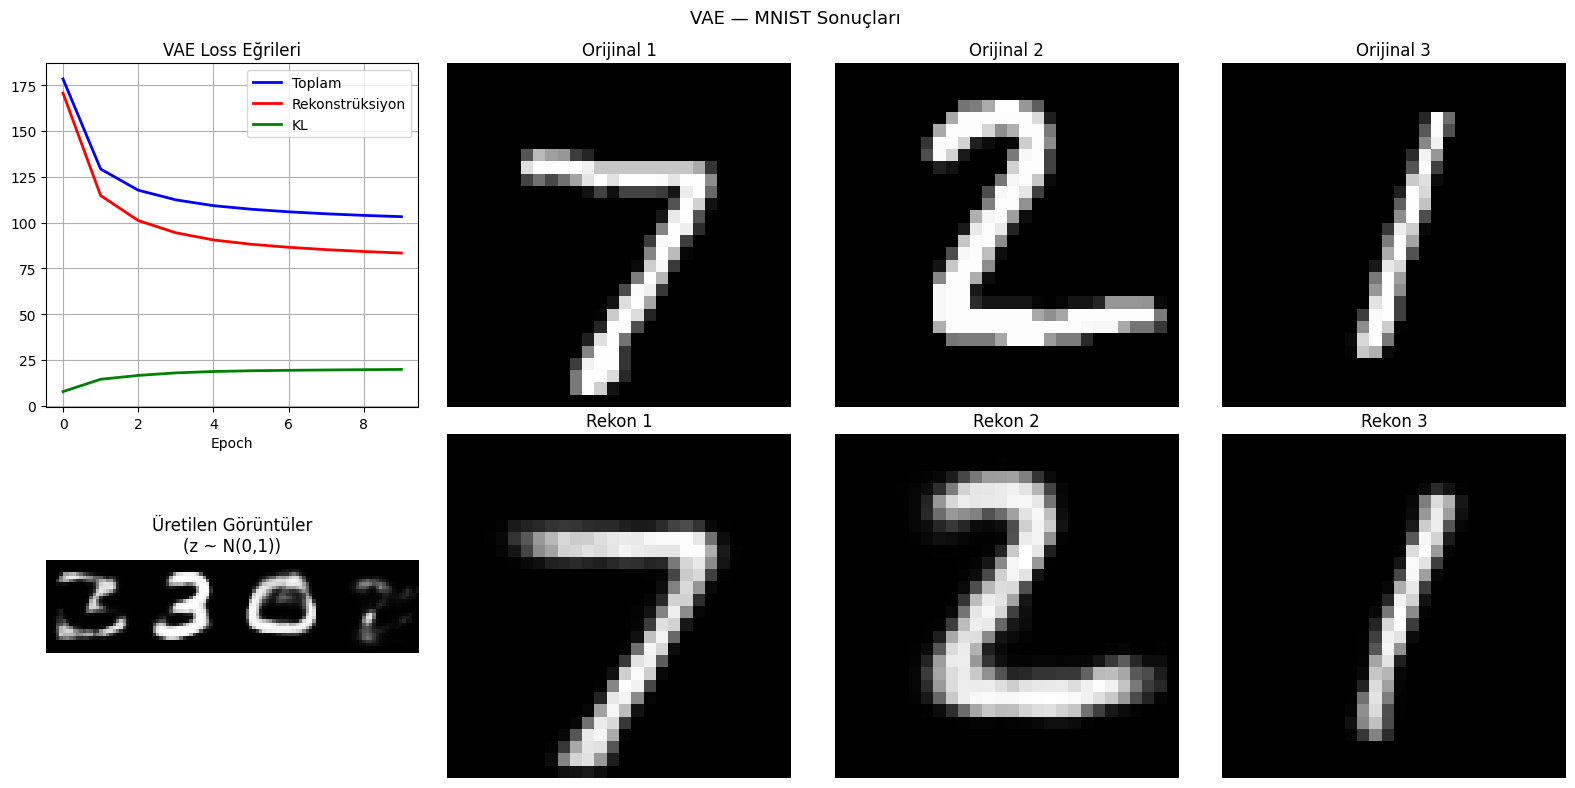


Latent uzay interpolasyonu:


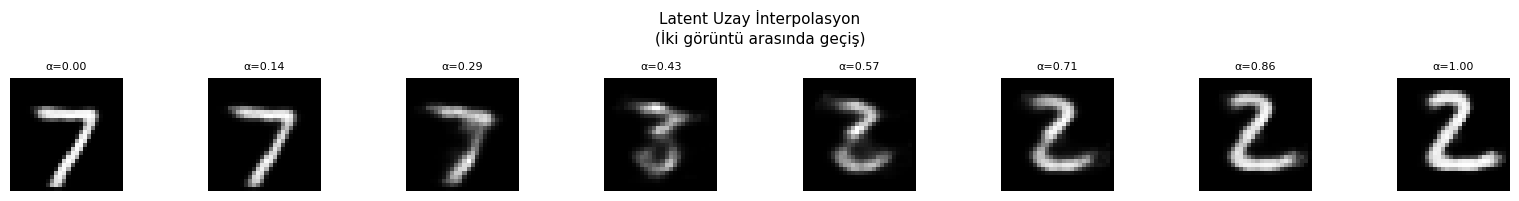

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Loss eğrileri
axes[0,0].plot(train_losses, 'b-', linewidth=2, label='Toplam')
axes[0,0].plot(recon_losses, 'r-', linewidth=2, label='Rekonstrüksiyon')
axes[0,0].plot(kl_losses, 'g-', linewidth=2, label='KL')
axes[0,0].set_title("VAE Loss Eğrileri")
axes[0,0].set_xlabel("Epoch")
axes[0,0].legend()
axes[0,0].grid(True)

# Orijinal vs Rekonstrüksiyon
vae.eval()
with torch.no_grad():
    x_sample, _ = next(iter(test_loader))
    x_recon, mu, log_var = vae(x_sample)

for i in range(3):
    # Orijinal
    axes[0, i+1].imshow(x_sample[i].reshape(28,28), cmap='gray')
    axes[0, i+1].set_title(f"Orijinal {i+1}")
    axes[0, i+1].axis('off')

    # Rekonstrüksiyon
    axes[1, i+1].imshow(x_recon[i].reshape(28,28), cmap='gray')
    axes[1, i+1].set_title(f"Rekon {i+1}")
    axes[1, i+1].axis('off')

# Latent uzaydan yeni örnekler üret
with torch.no_grad():
    z_random = torch.randn(8, 20)
    generated = vae.decode(z_random)

axes[1,0].imshow(
    generated[:4].reshape(4, 28, 28).permute(1,0,2).reshape(28, 112),
    cmap='gray')
axes[1,0].set_title("Üretilen Görüntüler\n(z ~ N(0,1))")
axes[1,0].axis('off')

plt.suptitle("VAE — MNIST Sonuçları", fontsize=13)
plt.tight_layout()
plt.show()

# Latent uzay interpolasyon
print("\nLatent uzay interpolasyonu:")
with torch.no_grad():
    # İki görüntü arasında geçiş
    x1, x2 = x_sample[0:1], x_sample[1:2]
    mu1, _ = vae.encode(x1)
    mu2, _ = vae.encode(x2)

    fig, axes_interp = plt.subplots(1, 8, figsize=(16, 2))
    for i, alpha in enumerate(np.linspace(0, 1, 8)):
        z_interp = (1-alpha) * mu1 + alpha * mu2
        x_interp = vae.decode(z_interp)
        axes_interp[i].imshow(x_interp.reshape(28,28), cmap='gray')
        axes_interp[i].set_title(f"α={alpha:.2f}", fontsize=8)
        axes_interp[i].axis('off')

    plt.suptitle("Latent Uzay İnterpolasyon\n(İki görüntü arasında geçiş)",
                fontsize=11)
    plt.tight_layout()
    plt.show()